# 09. PyTorch Model Deployment

## What is machine learning model deployment?

**Machine learning model deployment** is the process of making your machine learning model accessible to someone or something else.

Someone else being a person who can interact with your model in some way. 

For example, someone taking a photo on their smartphone of food and then having our FoodVision Mini model classify it into pizza, steak or sushi.

Something else might be another program, app or even another model that interacts with your machine learning model(s). 

For example, a banking database might rely on a machine learning model making predictions as to whether a transaction is fraudulent or not before transferring funds.

Or an operating system may lower its resource consumption based on a machine learning model making predictions on how much power someone generally uses at specific times of day.

These use cases can be mixed and matched as well.

For example, a Tesla car's computer vision system will interact with the car's route planning program (something else) and then the route planning program will get inputs and feedback from the driver (someone else).

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-what-is-model-deployment-someone-or-something-else.png" width=900 alt="two use cases for model deployment, making your model available to someone else, for example, someone using it in an app, or making it available to something else such as another program or model"/> 

*Machine learning model deployment involves making your model available to someone or something else. For example, someone might use your model as part of a food recognition app (such as FoodVision Mini or [Nutrify](https://nutrify.app)). And something else might be another model or program using your model such as a banking system using a machine learning model to detect if a transaction is fraud or not.* 
          
          

### Where's it going to go?

The main debate here is usually on-device (also called edge/in the browser) or on the cloud (a computer/server that isn't the *actual* device someone/something calls the model from). 

Both have their pros and cons.

| **Deployment location** | **Pros** | **Cons** | 
| ----- | ----- | ----- |
| **On-device (edge/in the browser)** | Can be very fast (since no data leaves the device) | Limited compute power (larger models take longer to run) | 
| | Privacy preserving (again no data has to leave the device) | Limited storage space (smaller model size required) | 
| | No internet connection required (sometimes) | Device-specific skills often required | 
| | | | 
| **On cloud** | Near unlimited compute power (can scale up when needed) | Costs can get out of hand (if proper scaling limits aren't enforced) |
| | Can deploy one model and use everywhere (via API) | Predictions can be slower due to data having to leave device and predictions having to come back (network latency) |
| | Links into existing cloud ecosystem | Data has to leave device (this may cause privacy concerns) |

### How's it going to function?

Back to the ideal use case, when you deploy your machine learning model, how should it work?

As in, would you like predictions returned immediately?

Or is it okay for them to happen later?

These two scenarios are generally referred to as:

* **Online (real-time)** - Predictions/inference happen **immediately**. For example, someone uploads an image, the image gets transformed and predictions are returned or someone makes a purchase and the transaction is verified to be non-fraudulent by a model so the purchase can go through.
* **Offline (batch)** - Predictions/inference happen **periodically**. For example, a photos application sorts your images into different categories (such as beach, mealtime, family, friends) whilst your mobile device is plugged into charge.

> **Note:** "Batch" refers to inference being performed on multiple samples at a time. However, to add a little confusion, batch processing can happen immediately/online (multiple images being classified at once) and/or offline (multiple images being predicted/trained on at once).  

The main difference between each being: predictions being made immediately or periodically.

### Ways to deploy a machine learning model

| **Tool/resource** | **Deployment type** | 
| ----- | ----- |
| [Google's ML Kit](https://developers.google.com/ml-kit) | On-device (Android and iOS) | 
| [Apple's Core ML](https://developer.apple.com/documentation/coreml) and [`coremltools` Python package](https://coremltools.readme.io/docs) | On-device (all Apple devices) | 
| [Amazon Web Service's (AWS) Sagemaker](https://aws.amazon.com/sagemaker/) | Cloud | 
| [Google Cloud's Vertex AI](https://cloud.google.com/vertex-ai) | Cloud |
| [Microsoft's Azure Machine Learning](https://azure.microsoft.com/en-au/services/machine-learning/) | Cloud |
| [Hugging Face Spaces](https://huggingface.co/spaces) | Cloud |
| API with [FastAPI](https://fastapi.tiangolo.com) | Cloud/self-hosted server |
| API with [TorchServe](https://pytorch.org/serve/) | Cloud/self-hosted server | 
| [ONNX (Open Neural Network Exchange)](https://onnx.ai/index.html) | Many/general |
| Many more... ||

> **Note:** An [application programming interface (API)](https://en.wikipedia.org/wiki/API) is a way for two (or more) computer programs to interact with each other. For example, if your model was deployed as API, you would be able to write a program that could send data to it and then receive predictions back.

The best ways to do so is by turning your machine learning model into a demo app with [Gradio](https://gradio.app) and then deploying it on Hugging Face Spaces.

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-tools-and-places-to-deploy-ml-models.png" alt="tools and places to deploy machine learning models" width=900/>


## 0. Getting Setup

In [ ]:
import torch
import torchvision
import matplotlib.pyplot as plt
import pandas as pd

from torch import nn
from torchvision import transforms
from pathlib import Path
from PIL import Image
from timeit import default_timer as timer
from tqdm.auto import tqdm
from typing import List, Dict

from scripts import data_setup, engine, utils
from helper_functions import download_data, set_seeds, set_device, plot_loss_curves

In [2]:
device = set_device()

## 1. Getting Data

In [ ]:
# Download pizza, steak, sushi images from GitHub
data_20_percent_path = download_data(
    source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
    destination="pizza_steak_sushi_20_percent",
)

data_20_percent_path

[INFO] data/pizza_steak_sushi_20_percent directory exists, skipping download.


PosixPath('data/pizza_steak_sushi_20_percent')

In [4]:
# Setup directory paths to train and test images
train_dir = data_20_percent_path / "train"
test_dir = data_20_percent_path / "test"

## 2. Creating an EffNetB2 feature extractor

In [5]:
# setup pretrained EffNetB2 weights
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT

# Get EffNetB2 transforms
effnetb2_transforms = effnetb2_weights.transforms()

# Setup pretrained model
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights)

# Freeze the base layers in the model
for param in effnetb2.parameters():
  param.requires_grad = False

In [6]:
# Check out EffNetB2 classifier head
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=1000, bias=True)
)

In [7]:
# update the classifier to suit the current problem
effnetb2.classifier = nn.Sequential(
  nn.Dropout(p=0.3, inplace=True),
  nn.Linear(in_features=1408, out_features=3)
)

### 2.1 Creating a function to make an EffNetB2 feature extractor

In [8]:
def create_effnetb2_model(num_classes: int = 3, seed:int=42):
    """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head.
            Defaults to 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model.
        transforms (torchvision.transforms): EffNetB2 image transforms.
    """
    # Create EffNetB2 pretrained weights, transforms and model
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    # Freeze all layers in base model
    for param in model.parameters():
        param.requires_grad = False

    # Change classifier head with random seed for reproducibility
    torch.manual_seed(seed=seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True), nn.Linear(in_features=1408, out_features=num_classes)
    )
    
    return model, transforms

In [9]:
effnetb2, effnetb2_transforms = create_effnetb2_model(num_classes=3, seed=42)

### 2.2 Creating DataLoaders for EffNetB2

In [10]:
train_dataloader_effnetb2, test_dataloader_effnetb2, class_names_effnetb2 = data_setup.create_dataloaders(
  train_dir=train_dir,
  test_dir=test_dir,
  transform=effnetb2_transforms,
  batch_size=32
)

### 2.3 Training EffNet2 feature extractor

In [11]:
optimizer = torch.optim.Adam(params=effnetb2.parameters(), lr=1e-3)

loss_fn = nn.CrossEntropyLoss()

set_seeds()
effnetb2_results = engine.train(
  model=effnetb2,
  train_dataloader=train_dataloader_effnetb2,
  test_dataloader=test_dataloader_effnetb2,
  optimizer=optimizer,
  loss_fn=loss_fn,
  epochs=10,
  device=device
)

100%|██████████| 1/1 [01:19<00:00, 79.80s/it]

Epoch: 1 | train_loss: 0.9817 | train_acc: 0.5729 | test_loss: 0.7343 | test_acc: 0.9625


### 2.4 Inspecting EffNetB2 loss curve

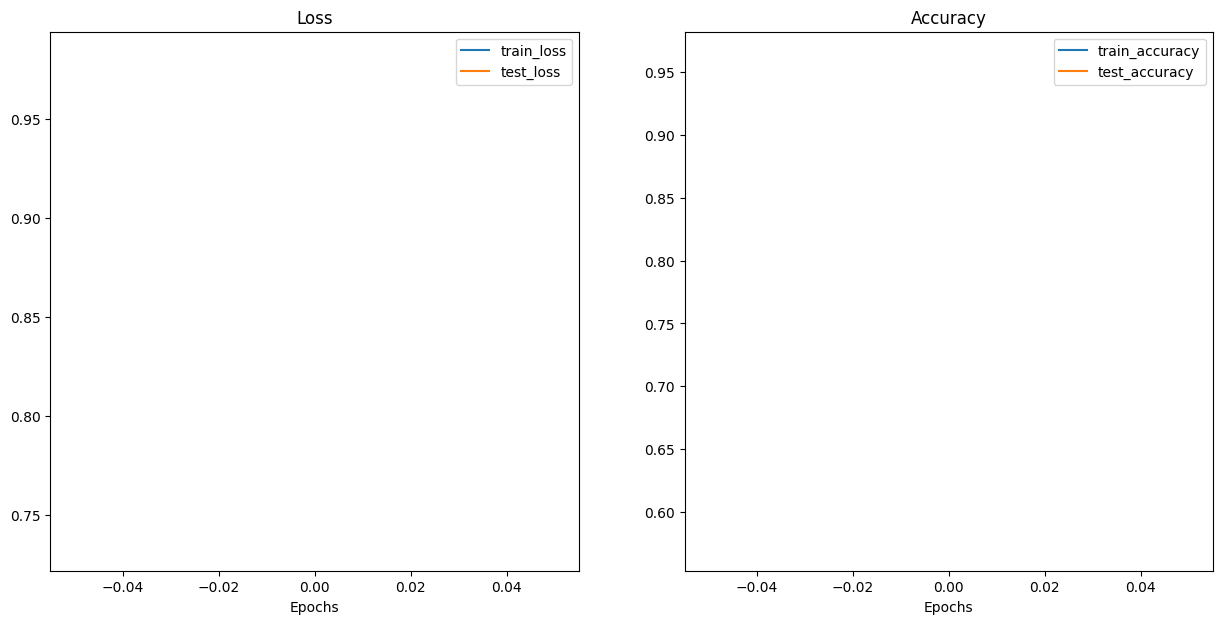

In [12]:
plot_loss_curves(effnetb2_results)

### 2.5 Save EffNetB2 Model

In [13]:
utils.save_model(model=effnetb2,
                 target_dir="models",
                 model_name="09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi.pth")


[INFO] Saving model to: models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi.pth


### 2.6 Checking the EffNetB2 feature extractor size

In [14]:
pretrained_effnetb2_model_size = Path(
    "models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi.pth"
).stat().st_size // (1024 * 1024)

print(
    f"Pretrained EffNetB2 feature extractor model size: {pretrained_effnetb2_model_size} MB"
)

Pretrained EffNetB2 feature extractor model size: 29 MB


In [15]:
# Count number of parameters in EffNetB2
effnetb2_total_params = sum(torch.numel(param) for param in effnetb2.parameters())
effnetb2_total_params

7705221

In [16]:
# Create a dictionary with EffNetB2 statistics
effnetb2_stats = {
    "test_loss": effnetb2_results["test_loss"][-1],
    "test_acc": effnetb2_results["test_acc"][-1],
    "number_of_parameters": effnetb2_total_params,
    "model_size (MB)": pretrained_effnetb2_model_size,
}
effnetb2_stats

{'test_loss': 0.734327745437622,
 'test_acc': 0.9625,
 'number_of_parameters': 7705221,
 'model_size (MB)': 29}

## 3. Creating a ViT feature extractor

In [17]:
# checking out ViT heads layer
vit = torchvision.models.vit_b_16()
vit.heads

Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

### 3.1 Creating a function to make an ViT feature extractor

In [18]:
# Create ViT model function
def create_vit_model(num_classes:int=3, seed:int=42):
    """Creates a ViT-B/16 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of target classes. Defaults to 3.
        seed (int, optional): random seed value for output layer. Defaults to 42.

    Returns:
        model (torch.nn.Module): ViT-B/16 feature extractor model.
        transforms (torchvision.transforms): ViT-B/16 image transforms.
    """
    
    # create weights, transforms and model
    weights = torchvision.models.ViT_B_16_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.vit_b_16(weights=weights)
    
    # Freeze all layers in model
    for param in model.parameters():
      param.requires_grad=False
      
    # Change the classifer head
    torch.manual_seed(seed=seed)
    model.heads = nn.Sequential(
        nn.Linear(in_features=768,
                  out_features=num_classes,
                  bias=True)
    )
    
    return model, transforms

In [19]:
vit_model, vit_transforms = create_vit_model(num_classes=3, seed=42)

### 3.2 Creating DataLoaders for ViT

In [20]:
train_dataloader_vit, test_dataloader_vit, class_names_vit = (
    data_setup.create_dataloaders(
        train_dir=train_dir,
        test_dir=test_dir,
        transform=vit_transforms,
        batch_size=32,
    )
)


### 3.3 Training ViT feature extractor

In [21]:
optimizer = torch.optim.Adam(params=vit_model.parameters(), lr=1e-3)

loss_fn = nn.CrossEntropyLoss()

set_seeds()
vit_results = engine.train(
    model=vit_model,
    train_dataloader=train_dataloader_vit,
    test_dataloader=test_dataloader_vit,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=10,
    device=device,
)


100%|██████████| 1/1 [01:29<00:00, 89.47s/it]

Epoch: 1 | train_loss: 0.7020 | train_acc: 0.7521 | test_loss: 0.2714 | test_acc: 0.9381


### 3.4 Inspecting ViT loss curve

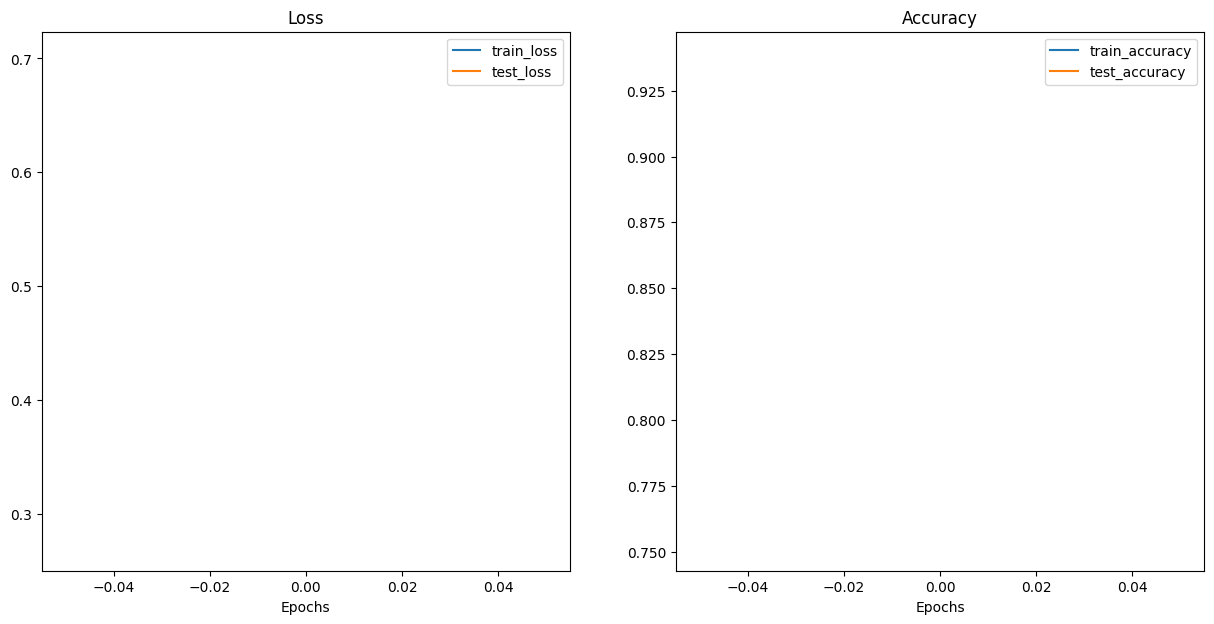

In [22]:
plot_loss_curves(vit_results)

### 3.5 Save ViT Model

In [23]:
utils.save_model(
    model=vit_model,
    target_dir="models",
    model_name="09_pretrained_vit_feature_extractor_pizza_steak_sushi.pth",
)

[INFO] Saving model to: models/09_pretrained_vit_feature_extractor_pizza_steak_sushi.pth


### 3.6 Checking the Vit feature extractor size

In [24]:
pretrained_vit_model_size = Path(
    "models/09_pretrained_vit_feature_extractor_pizza_steak_sushi.pth"
).stat().st_size // (1024 * 1024)

print(
    f"Pretrained ViT feature extractor model size: {pretrained_vit_model_size} MB"
)

Pretrained ViT feature extractor model size: 327 MB


In [ ]:
# Count number of parameters in ViT
vit_total_params = sum(torch.numel(param) for param in vit_model.parameters())
vit_total_params

86567656

In [ ]:
# Create a dictionary with ViT statistics
vit_stats = {
    "test_loss": vit_results["test_loss"][-1],
    "test_acc": vit_results["test_acc"][-1],
    "number_of_parameters": vit_total_params,
    "model_size (MB)": pretrained_vit_model_size,
}
vit_stats


{'test_loss': 0.271392697095871,
 'test_acc': 0.9380681818181819,
 'number_of_parameters': 86567656,
 'model_size (MB)': 327}

## 4. Making predictions with our trained models and timing them

To find out how long each of our models take to performance inference, let's create a function called `pred_and_store()` to iterate over each of the test dataset images one by one and perform a prediction. 

We'll time each of the predictions as well as store the results in a common prediction format: a list of dictionaries (where each element in the list is a single prediction and each sinlge prediction is a dictionary). 

> **Note:** We time the predictions one by one rather than by batch because when our model is deployed, it will likely only be making a prediction on one image at a time. As in, someone takes a photo and our model predicts on that single image.

Since we'd like to make predictions across all the images in the test set, let's first get a list of all of the test image paths so we can iterate over them. 

To do so, we'll use Python's [`pathlib.Path("target_dir").glob("*/*.jpg"))`](https://docs.python.org/3/library/pathlib.html#basic-use) to find all of the filepaths in a target directory with the extension `.jpg` (all of our test images).

In [27]:
# Get all test data paths
print(f"[INFO] Finding all filepaths ending with '.jpg' in directory: {test_dir}")
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))
test_data_paths[:5]

[INFO] Finding all filepaths ending with '.jpg' in directory: data/pizza_steak_sushi_20_percent/test


[PosixPath('data/pizza_steak_sushi_20_percent/test/steak/413497.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/steak/2246332.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/steak/2475366.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/steak/1982192.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/steak/2353677.jpg')]

### 4.1 Creating a function to make predictions across the test dataset

In [34]:
def pred_and_store(
  paths: List[Path],
  model: torch.nn.Module,
  transform: torchvision.transforms,
  class_names: List[str],
  device: str = "cpu"
):
    # empty list to store predictions for each sample
    pred_list = []

    # Loop through target paths
    for path in tqdm(paths):
        # empty dict to store prediction
        pred_dict = {}

        # Get sample path
        pred_dict["image_path"] = path
        class_name = path.parent.stem
        pred_dict["class_name"] = class_name
        
        # start timer
        start_time = timer()
        
        # open image
        img = Image.open(path)
        
        # transform image
        transformed_image = transform(img).unsqueeze(0).to(device)
        
        # prepare model
        model.to(device)
        model.eval()
        with torch.inference_mode():
            pred_logit = model(transformed_image)  # perform inference on target sample
            pred_prob = torch.softmax(pred_logit, dim=1)  # turn logits into prediction probabilities
            pred_label = torch.argmax(pred_prob, dim=1)  # turn prediction probabilities into prediction label
            pred_class = class_names[pred_label.cpu()]  # hardcode prediction class to be on CPU
            
            pred_dict["pred_prob"] = round(pred_prob.unsqueeze(0).max().cpu().item(), 4)
            pred_dict["pred_class"] = pred_class
            
            # End Timer
            end_time = timer()
            pred_dict["time_for_pred"] = round(end_time - start_time, 4)
        
        # does pred match true label
        pred_dict["correct"] = class_name == pred_class
        
        # Add dictionary to list of preds
        pred_list.append(pred_dict)
      
    return pred_list

### 4.2 EffNetB2 Performance

In [35]:
# Make predictions across test dataset with EffNetB2
effnetb2_test_pred_dicts = pred_and_store(
    paths=test_data_paths,
    model=effnetb2,
    transform=effnetb2_transforms,
    class_names=class_names_effnetb2,
    device="cpu",
)  # make predictions on CPU


100%|██████████| 150/150 [00:28<00:00,  5.25it/s]


In [36]:
# inspect the first 2 predictions
effnetb2_test_pred_dicts[: 2]

[{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/413497.jpg'),
  'class_name': 'steak',
  'pred_prob': 0.525,
  'pred_class': 'steak',
  'time_for_pred': 0.8102,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/2246332.jpg'),
  'class_name': 'steak',
  'pred_prob': 0.588,
  'pred_class': 'steak',
  'time_for_pred': 0.1908,
  'correct': True}]

In [37]:
effnetb2_test_pred_df = pd.DataFrame(effnetb2_test_pred_dicts)
effnetb2_test_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi_20_percent/test/steak/4...,steak,0.5250,steak,0.8102,True
1,data/pizza_steak_sushi_20_percent/test/steak/2...,steak,0.5880,steak,0.1908,True
2,data/pizza_steak_sushi_20_percent/test/steak/2...,steak,0.4682,steak,0.1891,True
3,data/pizza_steak_sushi_20_percent/test/steak/1...,steak,0.3805,steak,0.1879,True
4,data/pizza_steak_sushi_20_percent/test/steak/2...,steak,0.4857,steak,0.1852,True


In [38]:
# Check number of correct predictions
effnetb2_test_pred_df.correct.value_counts()

correct
True     144
False      6
Name: count, dtype: int64

In [39]:
# Find the average time per prediction
effnetb2_average_time_per_pred = round(effnetb2_test_pred_df.time_for_pred.mean(), 4)
print(f"EffNetB2 average time per prediction: {effnetb2_average_time_per_pred} seconds")

EffNetB2 average time per prediction: 0.1901 seconds


In [40]:
# Add EffNetB2 average prediction time to stats dictionary
effnetb2_stats["time_per_pred_cpu"] = effnetb2_average_time_per_pred
effnetb2_stats

{'test_loss': 0.734327745437622,
 'test_acc': 0.9625,
 'number_of_parameters': 7705221,
 'model_size (MB)': 29,
 'time_per_pred_cpu': np.float64(0.1901)}

### 4.3 ViT Performance

In [41]:
# Make list of prediction dictionaries with ViT feature extractor model on test images
vit_test_pred_dicts = pred_and_store(
    paths=test_data_paths,
    model=vit,
    transform=vit_transforms,
    class_names=class_names_vit,
    device="cpu",
)

100%|██████████| 150/150 [00:15<00:00,  9.84it/s]


In [42]:
# inspect the first 2 predictions
vit_test_pred_dicts[:2]

[{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/413497.jpg'),
  'class_name': 'steak',
  'pred_prob': 0.001,
  'pred_class': 'pizza',
  'time_for_pred': 1.2269,
  'correct': False},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/2246332.jpg'),
  'class_name': 'steak',
  'pred_prob': 0.001,
  'pred_class': 'pizza',
  'time_for_pred': 0.1175,
  'correct': False}]

In [43]:
vit_test_pred_df = pd.DataFrame(vit_test_pred_dicts)
vit_test_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi_20_percent/test/steak/4...,steak,0.001,pizza,1.2269,False
1,data/pizza_steak_sushi_20_percent/test/steak/2...,steak,0.001,pizza,0.1175,False
2,data/pizza_steak_sushi_20_percent/test/steak/2...,steak,0.001,pizza,0.0936,False
3,data/pizza_steak_sushi_20_percent/test/steak/1...,steak,0.001,pizza,0.0924,False
4,data/pizza_steak_sushi_20_percent/test/steak/2...,steak,0.001,pizza,0.0915,False


In [44]:
# Check number of correct predictions
vit_test_pred_df.correct.value_counts()

correct
False    104
True      46
Name: count, dtype: int64

In [45]:
# Find the average time per prediction
vit_average_time_per_pred = round(vit_test_pred_df.time_for_pred.mean(), 4)
print(f"ViT average time per prediction: {vit_average_time_per_pred} seconds")

ViT average time per prediction: 0.1014 seconds


In [46]:
# Add EffNetB2 average prediction time to stats dictionary
vit_stats["time_per_pred_cpu"] = vit_average_time_per_pred
vit_stats

{'test_loss': 0.271392697095871,
 'test_acc': 0.9380681818181819,
 'number_of_parameters': 86567656,
 'model_size (MB)': 327,
 'time_per_pred_cpu': np.float64(0.1014)}

## 5. Comparing model results, prediction times and size

In [47]:
# Turn stat dictionaries into DataFrame
df = pd.DataFrame([effnetb2_stats, vit_stats])

# Add column for model names
df["model"] = ["EffNetB2", "ViT"]

# Convert accuracy to percentages
df["test_acc"] = round(df["test_acc"] * 100, 2)

df

,test_loss,test_acc,number_of_parameters,model_size (MB),time_per_pred_cpu,model
0,0.734328,96.25,7705221,29,0.1901,EffNetB2
1,0.271393,93.81,86567656,327,0.1014,ViT


In [48]:
# Compare ViT to EffNetB2 across different characteristics
pd.DataFrame(
    data=(
        df.set_index("model").loc["ViT"] / df.set_index("model").loc["EffNetB2"]
    ),  # divide ViT statistics by EffNetB2 statistics
    columns=["ViT to EffNetB2 ratios"],
).T

,test_loss,test_acc,number_of_parameters,model_size (MB),time_per_pred_cpu
ViT to EffNetB2 ratios,0.36958,0.974649,11.234935,11.275862,0.533403


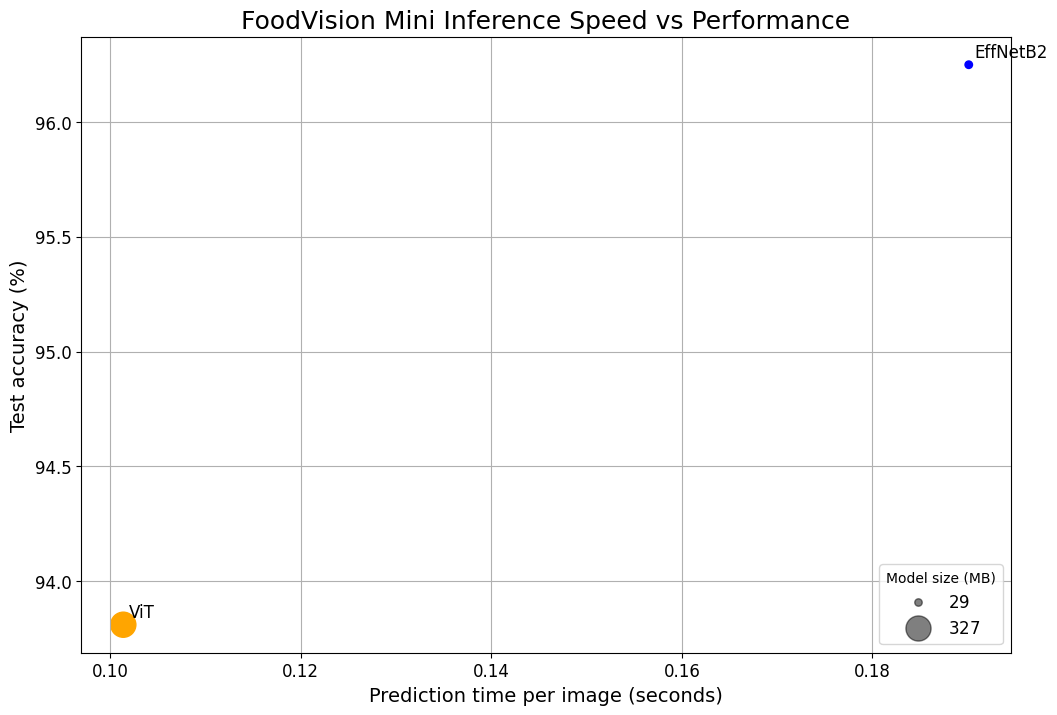

In [50]:
# 1. Create a plot from model comparison DataFrame
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    data=df,
    x="time_per_pred_cpu",
    y="test_acc",
    c=["blue", "orange"],  # what colours to use?
    s="model_size (MB)",
)  # size the dots by the model sizes

# 2. Add titles, labels and customize fontsize for aesthetics
ax.set_title("FoodVision Mini Inference Speed vs Performance", fontsize=18)
ax.set_xlabel("Prediction time per image (seconds)", fontsize=14)
ax.set_ylabel("Test accuracy (%)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True)

# 3. Annotate with model names
for index, row in df.iterrows():
    ax.annotate(
        text=row[
            "model"
        ],  # note: depending on your version of Matplotlib, you may need to use "s=..." or "text=...", see: https://github.com/faustomorales/keras-ocr/issues/183#issuecomment-977733270
        xy=(row["time_per_pred_cpu"] + 0.0006, row["test_acc"] + 0.03),
        size=12,
    )

# 4. Create a legend based on model sizes
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.5)
model_size_legend = ax.legend(
    handles, labels, loc="lower right", title="Model size (MB)", fontsize=12
)

# Show the figure
plt.show()


## 6. FoodVision Mini - Gradio demo

In [51]:
import gradio as gr
print(f"Gradio version: {gr.__version__}")

Gradio version: 5.34.0


### 6.1 Gradio overview

The overall premise of Gradio is very similar to what we've been repeating throughout the course.

What are our **inputs** and **outputs**?

And how should we get there?

Well that's what our machine learning model does.

```
inputs -> ML model -> outputs
```

In our case, for FoodVision Mini, our inputs are images of food, our ML model is EffNetB2 and our outputs are classes of food (pizza, steak or sushi).

```
images of food -> EffNetB2 -> outputs
```

Though the concepts of inputs and outputs can be bridged to almost any other kind of ML problem.

Your inputs and outputs might be any combination of the following:
* Images
* Text
* Video
* Tabular data
* Audio
* Numbers
* & more

And the ML model you build will depend on your inputs and outputs.

Gradio emulates this paradigm by creating an interface ([`gradio.Interface()`](https://gradio.app/docs/#interface-header)) from inputs to outputs.

```
gradio.Interface(fn, inputs, outputs)
```

Where, `fn` is a Python function to map the `inputs` to the `outputs`.

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-gradio-workflow.png" alt="gradio workflow of inputs flowing into some kind of model or function and then producing outputs" width=900/>

*Gradio provides a very helpful `Interface` class to easily create an inputs -> model/function -> outputs workflow where the inputs and outputs could be almost anything you want. For example, you might input Tweets (text) to see if they're about machine learning or not or [input a text prompt to generate images](https://huggingface.co/blog/stable_diffusion).*

> **Note:** Gradio has a vast number of possible `inputs` and `outputs` options known as "Components" from images to text to numbers to audio to videos and more. You can see all of these in the [Gradio Components documentation](https://gradio.app/docs/#components).

### 6.2 Creating a function to map our inputs and outputs

In [52]:
# Put EffNetB2 on CPU
effnetb2.to("cpu")

# Check the device
next(iter(effnetb2.parameters())).device

device(type='cpu')

In [53]:
from typing import Tuple, Dict

def predict(img) -> Tuple[Dict, float]:
  """Transforms and performs a prediction on img and returns prediction and time taken.
  """
  start_time = timer()
  
  # transform the target image and add a batch dimension
  img = effnetb2_transforms(img).unsqueeze(0)
  
  # put the model into eval mode
  effnetb2.eval()
  with torch.inference_mode():
    pred_probs = torch.softmax(effnetb2(img), dim=1)
  
  pred_labels_and_probs = {
    class_names_effnetb2[i]: float(pred_probs[0][i]) for i in range(len(class_names_effnetb2))
  }
  
  # Calculate the prediction time
  pred_time = round(timer() - start_time, 5)
  
  # Return the prediction dictionary and prediction time 
  return pred_labels_and_probs, pred_time
  

In [54]:
import random
from PIL import Image

# Get a list of all test image filepaths
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))

# Randomly select a test image path
random_image_path = random.sample(test_data_paths, k=1)[0]

# Open the target image
image = Image.open(random_image_path)
print(f"[INFO] Predicting on image at path: {random_image_path}\n")

# Predict on the target image and print out the outputs
pred_dict, pred_time = predict(img=image)
print(f"Prediction label and probability dictionary: \n{pred_dict}")
print(f"Prediction time: {pred_time} seconds")

[INFO] Predicting on image at path: data/pizza_steak_sushi_20_percent/test/pizza/3486640.jpg

Prediction label and probability dictionary: 
{'pizza': 0.5993703603744507, 'steak': 0.18600712716579437, 'sushi': 0.21462245285511017}
Prediction time: 0.27207 seconds


### 6.3 Creating a list of example images

In [55]:
# Create a list of example inputs to our Gradio demo
example_list = [[str(filepath)] for filepath in random.sample(test_data_paths, k=3)]
example_list

[['data/pizza_steak_sushi_20_percent/test/sushi/124279.jpg'],
 ['data/pizza_steak_sushi_20_percent/test/steak/1972463.jpg'],
 ['data/pizza_steak_sushi_20_percent/test/pizza/2549661.jpg']]

### 6.4 Building a Gradio interface

Create a Gradio interface to replicate the workflow:

```
input: image -> transform -> predict with EffNetB2 -> output: pred, pred prob, time taken
```

In [58]:
import gradio as gr

# Create title, description strings
title = "FoodVision Mini 🍕🥩🍣"
description = "An EfficientNetB2 feature extractor computer vision model to classify images of food as pizza, steak or sushi."

# Create the Gradio demo
demo = gr.Interface(
    fn=predict,  # mapping function from input to output
    inputs=gr.Image(type="pil"),
    outputs=[
        gr.Label(num_top_classes=3, label="Predictions"),  # what are the outputs?
        gr.Number(label="Prediction time (s)"),
    ],  # our fn has two outputs, therefore we have two outputs
    examples=example_list,
    title=title,
    description=description
)

# Launch the demo!
# demo.launch(
#     debug=False,
# )

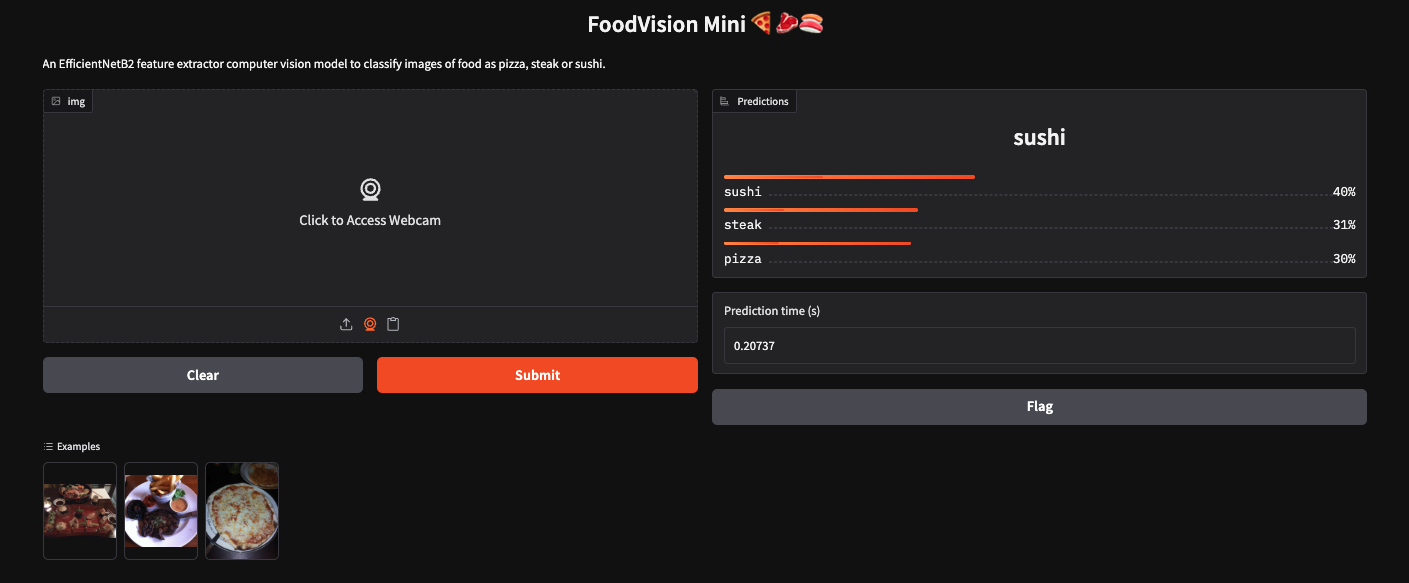